В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [181]:
import os
import warnings
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, f1_score

train_raw_df = pd.read_csv('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/train.csv')
display(train_df)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1749,1749,15741403.0,Ulyanova,671.0,France,Female,40.0,1.0,0.00,1.0,1.0,0.0,28257.89,0.0
14582,14582,15683483.0,Lettiere,756.0,France,Male,24.0,2.0,0.00,2.0,1.0,0.0,27474.81,0.0
3944,3944,15792489.0,Nucci,551.0,Germany,Female,40.0,6.0,131955.07,1.0,0.0,0.0,66463.62,1.0
270,270,15815070.0,Chukwuemeka,709.0,France,Male,30.0,2.0,0.00,2.0,0.0,1.0,80619.09,0.0
9660,9660,15755868.0,Ch'ang,686.0,France,Male,38.0,2.0,0.00,2.0,1.0,0.0,189366.04,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4986,4986,15750808.0,T'ien,713.0,France,Female,27.0,4.0,0.00,2.0,1.0,0.0,58907.08,0.0
8405,8405,15780212.0,Chien,825.0,France,Male,30.0,1.0,0.00,2.0,0.0,1.0,138380.11,0.0
9550,9550,15691627.0,Fyodorova,714.0,France,Male,47.0,7.0,0.00,1.0,0.0,0.0,74870.99,1.0
2775,2775,15602479.0,L?,648.0,France,Male,30.0,8.0,0.00,2.0,1.0,1.0,102908.63,0.0


In [182]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['Exited']
)

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [183]:
input_cols = train_df.drop(columns=['Exited']).columns.tolist()[2:]
target_col = ['Exited']

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [184]:
numeric_cols = train_inputs.select_dtypes(include='number').columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

Ознайомлюємось з даними

In [185]:
train_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3145 entries, 14396 to 12712
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Surname          3145 non-null   object 
 1   CreditScore      3145 non-null   float64
 2   Geography        3145 non-null   object 
 3   Gender           3145 non-null   object 
 4   Age              3145 non-null   float64
 5   Tenure           3145 non-null   float64
 6   Balance          3145 non-null   float64
 7   NumOfProducts    3145 non-null   float64
 8   HasCrCard        3145 non-null   float64
 9   IsActiveMember   3145 non-null   float64
 10  EstimatedSalary  3145 non-null   float64
dtypes: float64(8), object(3)
memory usage: 294.8+ KB


In [186]:
train_inputs.isna().sum()

Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64

Бачимо, що всі дані заповнені. Пропущені колонки відсутні.

In [187]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,3145.00,3145.00,3145.00,3145.00,3145.00,3145.00,3145.0,3145.00
mean,657.89,37.72,5.01,43348.15,1.59,0.78,0.5,117662.43
std,73.53,8.27,2.80,59769.19,0.54,0.41,0.5,46092.52
min,431.00,19.00,0.00,0.00,1.00,0.00,0.0,447.73
25%,602.00,32.00,3.00,0.00,1.00,1.00,0.0,83058.14
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.0,122960.98
75%,708.00,42.00,7.00,109327.65,2.00,1.00,1.0,156787.34
max,850.00,72.00,10.00,209767.31,4.00,1.00,1.0,199493.38


Числові колонки не мають пропущених значень і на перший погляд виглядають логічними. Будемо їх масштабувати, щоб значення були в одному діапазоні.

In [ ]:
plt.figure(figsize=(10, 8))
corr = train_inputs[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Числові ознаки: кореляційна матриця')
plt.savefig('corr_numeric_features.png', dpi=300, bbox_inches='tight')
plt.show()

Після побудови кореляційної матриці бачимо, що більшість числових ознак не мають дуже сильних лінійних зв’язків між собою. Це означає, що дані в цілому добре підходять для подальшого навчання моделі. Водночас окремі ознаки можуть бути корисними для прогнозування відтоку клієнтів, тому їх залишаємо для моделі.

In [ ]:
train_targets[target_col].value_counts(normalize = True)

Exited
0.0       0.796541
1.0       0.203459
Name: proportion, dtype: float64

In [ ]:
scaler = MinMaxScaler()
scaler.fit(train_inputs[numeric_cols])
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [ ]:
train_inputs[numeric_cols]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
1749,0.572792,0.396226,0.1,0.000000,0.000000,1.0,0.0,0.139717
14582,0.775656,0.094340,0.2,0.000000,0.333333,1.0,0.0,0.135783
3944,0.286396,0.396226,0.6,0.629054,0.000000,0.0,0.0,0.331662
270,0.663484,0.207547,0.2,0.000000,0.333333,0.0,1.0,0.402779
9660,0.608592,0.358491,0.2,0.000000,0.333333,1.0,0.0,0.949121
...,...,...,...,...,...,...,...,...
4986,0.673031,0.150943,0.4,0.000000,0.333333,1.0,0.0,0.293698
8405,0.940334,0.207547,0.1,0.000000,0.333333,0.0,1.0,0.692969
9550,0.675418,0.528302,0.7,0.000000,0.000000,0.0,0.0,0.373900
2775,0.517900,0.207547,0.8,0.000000,0.333333,1.0,1.0,0.514761


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [ ]:
train_inputs[categorical_cols].nunique()

Surname      533
Geography      3
Gender         2
dtype: int64

Колонка `Surname` є нерелевантною для побудови моделі, тому ми не будемо її використовувати. Будемо кодувати дві інші колонки.

In [ ]:
categorical_cols = train_inputs.drop(columns=['Surname']).select_dtypes(include='object').columns.tolist()
encoder.fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
print(encoded_cols)

['Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [ ]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [ ]:
display(train_inputs.head())

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
1749,Ulyanova,0.572792,France,Female,0.396226,0.1,0.000000,0.000000,1.0,0.0,0.139717,1.0,0.0,0.0,1.0,0.0
14582,Lettiere,0.775656,France,Male,0.094340,0.2,0.000000,0.333333,1.0,0.0,0.135783,1.0,0.0,0.0,0.0,1.0
3944,Nucci,0.286396,Germany,Female,0.396226,0.6,0.629054,0.000000,0.0,0.0,0.331662,0.0,1.0,0.0,1.0,0.0
270,Chukwuemeka,0.663484,France,Male,0.207547,0.2,0.000000,0.333333,0.0,1.0,0.402779,1.0,0.0,0.0,0.0,1.0
9660,Ch'ang,0.608592,France,Male,0.358491,0.2,0.000000,0.333333,1.0,0.0,0.949121,1.0,0.0,0.0,0.0,1.0


In [ ]:
display(val_inputs.head())

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
3558,Tung,0.486874,France,Male,0.283019,0.7,0.000000,0.333333,1.0,1.0,0.413808,1.0,0.0,0.0,0.0,1.0
13884,Chukwufumnanya,0.634845,France,Male,0.301887,0.8,0.000000,0.333333,1.0,0.0,0.791332,1.0,0.0,0.0,0.0,1.0
6558,Chukwuhaenye,0.513126,Germany,Male,0.320755,1.0,0.642598,0.000000,1.0,1.0,0.511689,0.0,1.0,0.0,0.0,1.0
6353,K'ung,0.501193,France,Male,0.320755,0.9,0.000000,0.333333,1.0,1.0,0.842882,1.0,0.0,0.0,0.0,1.0
13669,K?,0.272076,France,Male,0.509434,0.7,0.000000,0.333333,1.0,1.0,0.809520,1.0,0.0,0.0,0.0,1.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [ ]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (3932, 16)
train_targets: (3932, 1)
val_inputs: (983, 16)
val_targets: (983, 1)


In [159]:
out_dir = '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/prepared_data'

train_inputs.to_parquet(f'{out_dir}/train_inputs.parquet')
train_targets.to_parquet(f'{out_dir}/train_targets.parquet')
val_inputs.to_parquet(f'{out_dir}/val_inputs.parquet')
val_targets.to_parquet(f'{out_dir}/val_targets.parquet')

In [160]:
import os

In [161]:
os.listdir(out_dir)

['train_inputs.parquet',
 'train_targets.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [162]:
model = LogisticRegression(solver='liblinear')
model.fit(train_inputs[numeric_cols + encoded_cols], train_targets)

LogisticRegression(solver='liblinear')

In [163]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

train_preds = model.predict(X_train)

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

## Confusion matrix

In [164]:
cf = confusion_matrix(train_targets, train_preds, normalize='true')
cf

array([[0.96296296, 0.03703704],
       [0.45125   , 0.54875   ]])

In [165]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True, cmap='viridis', fmt='.2f', annot_kws={"color": "white"})
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

Accuracy: 87.87%


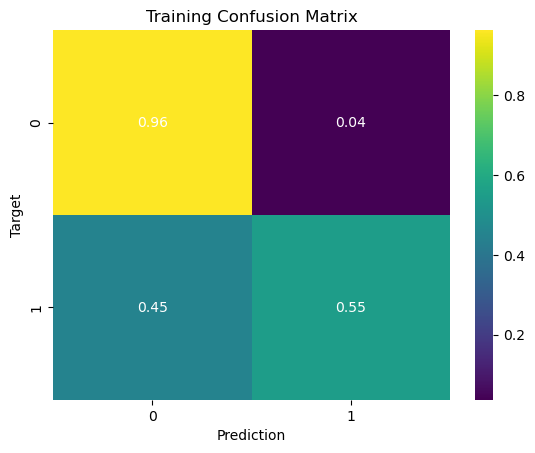

In [166]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 85.96%


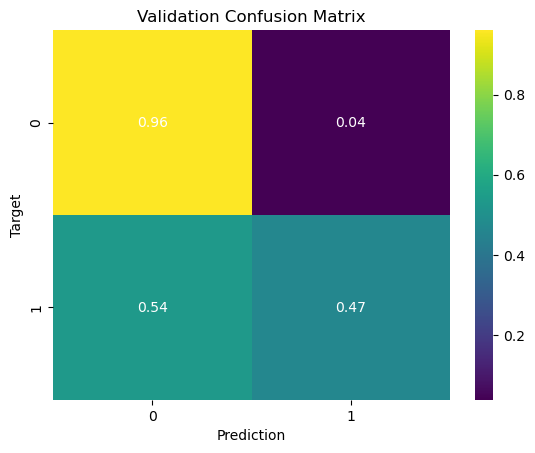

In [167]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

## ROC Curve, метрика AUROC

In [168]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {roc_auc:.2f}')

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc='lower right')
    plt.show()

AUROC for Training: 0.89


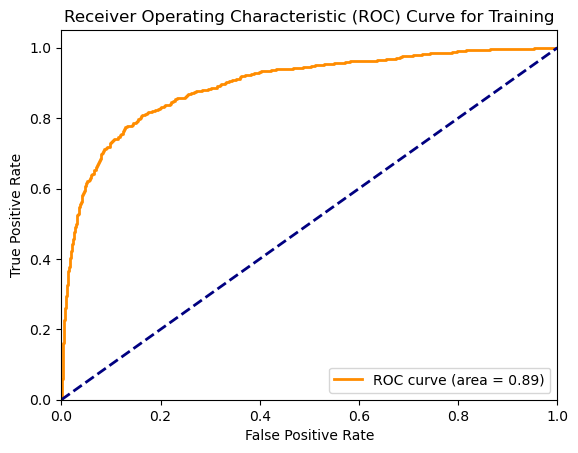

AUROC for Validation: 0.88


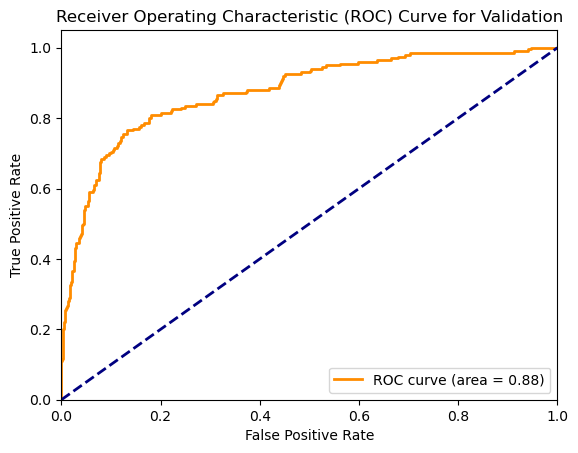

In [169]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

## Обчислення F1 

In [170]:
train_f1 = f1_score(train_targets, train_preds, pos_label=1)
val_f1 = f1_score(val_targets, val_preds, pos_label=1)
print(f'Train F1 Score: {train_f1:.4f}')
print(f'Val   F1 Score: {val_f1:.4f}')

Train F1 Score: 0.6480
Val   F1 Score: 0.5741


### Висновок про якість моделі

- **Confusion Matrix**: модель добре розпізнає клас 0 (не відтік), але погано виявляє клас 1 (відтік).
- **AUROC**: значення 0.88 відповідає задовільній/хорошій моделі.
- **F1 Score**: низький F1 для класу 1 свідчить, що модель пропускає багато реальних відтоків.

**Загальний висновок:** модель є **задовільною** — вона непогано розпізнає більшість клієнтів, які залишаються, але погано ловить тих, хто відтікає.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [171]:
majority_class = train_targets['Exited'].mode()[0]

majority_train_preds = [majority_class] * len(train_targets)
majority_val_preds = [majority_class] * len(val_targets)

# Accuracy of baseline vs trained model
train_acc = accuracy_score(train_targets['Exited'], majority_train_preds)
val_acc = accuracy_score(val_targets['Exited'], majority_val_preds)

model_train_acc = accuracy_score(train_targets['Exited'], train_preds)
model_val_acc = accuracy_score(val_targets['Exited'], val_preds)

print(f'Majority class: {majority_class}')
print(f'Baseline train accuracy: {train_acc:.4f}')
print(f'Baseline val accuracy:   {val_acc:.4f}')
print(f'Model train accuracy:    {model_train_acc:.4f}')
print(f'Model val accuracy:      {model_val_acc:.4f}')

Majority class: 0.0
Baseline train accuracy: 0.7965
Baseline val accuracy:   0.7965
Model train accuracy:    0.8787
Model val accuracy:      0.8596


Модель помітно краща аніж та, яка передбачає за мажоритарним класом.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [172]:
model_artifacts = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [173]:
joblib.dump(model_artifacts, '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts/model_artifacts.joblib')

['../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts/model_artifacts.joblib']

In [174]:
model_2 = joblib.load('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/artifacts/model_artifacts.joblib')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [175]:
warnings.filterwarnings("ignore")

def predict_raw_df(model, scaler, encoder, input_cols, numeric_cols, categorical_cols, encoded_cols, input_df: pd.DataFrame):
    input_df = input_df[input_cols].copy()
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

    encoded_data = encoder.transform(input_df[categorical_cols])
    encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols, index=input_df.index)

    X_input = pd.concat([input_df[numeric_cols], encoded_df], axis=1)
    prob = model.predict_proba(X_input)[:, 1]
    return prob

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [176]:
test_raw_df = pd.read_csv('../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/test.csv')
display(test_raw_df)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


In [177]:
test_raw_df["Exited"] = predict_raw_df(model, scaler, encoder, input_cols, numeric_cols, categorical_cols, encoded_cols, test_raw_df)

In [178]:
test_raw_df

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.080754
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.041428
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.167851
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.194634
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.057392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,0.021566
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,0.026533
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.019173
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.156092


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [179]:
sample_submission_file = pd.read_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/sample_submission.csv'
)

sample_submission_df = sample_submission_file.drop(columns=['Exited']).merge(
    test_raw_df[['id', 'Exited']],
    on='id',
    how='left'
)

display(sample_submission_df.head())

,id,Exited
0,15000,0.080754
1,15001,0.041428
2,15002,0.167851
3,15003,0.194634
4,15004,0.057392


In [180]:
sample_submission_df.to_csv(
    '../../Sample Data/bank-customer-churn-prediction-dlu-course-c-5/submission_log_reg.csv',
    index=False
)